#Step 1 - Dataset extraction
The following cell downloads and extracts the dataset and then generate the configuration dictionary, which is displayed above. This dictionary (cfg) contains details such as the paths for training, validation and testing images, the number of classes, the class names and Roboflow project details.

In [1]:
#Import dependencies
import os, hashlib, zipfile, urllib.request, yaml
from pathlib import Path

#Define dataset constants and paths
DATA_URL = "https://github.com/user-attachments/files/32692644/M4-U3.-.Assignment.v1i.yolov11.zip"
SHA256 = "087A862753D6427E53FA5615317F250693462B47974E048347102B423C7C5230"
ROOT = Path("/content/dataset")
ZIP_PATH = Path("/content/dataset.zip")

def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def find_data_yaml(root: Path):
    hits = list(root.rglob("data.yaml"))
    if not hits:
        raise FileNotFoundError(f"No data.yaml under {root}")
    return hits[0]

#Download dataset ZIP file and extract content into designated directory
already_ready = (ROOT / "data.yaml").exists() or any(ROOT.glob("*/data.yaml"))
if not already_ready:
    ROOT.mkdir(parents=True, exist_ok=True)
    if ZIP_PATH.exists():
        ZIP_PATH.unlink()
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    digest = sha256_file(ZIP_PATH)
    if digest != SHA256.lower():
        ZIP_PATH.unlink(missing_ok=True)
        raise AssertionError(f"Checksum mismatch: {digest}")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(ROOT)

#Update dataset with training, validation and testing paths and print updated dataset configuration
cfg_path = find_data_yaml(ROOT)
dataset_root = cfg_path.parent
cfg = yaml.safe_load(cfg_path.read_text())
cfg["path"] = str(dataset_root)
cfg["train"] = "train/images"
cfg["val"] = "valid/images"
if (dataset_root / "test" / "images").is_dir():
    cfg["test"] = "test/images"
else:
    cfg.pop("test", None)
cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
print(cfg)
data=str(cfg_path)

{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['Concrete spalling'], 'roboflow': {'workspace': 'valentina-votter', 'project': 'm4-u3-assignment-d3j9b', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/valentina-votter/m4-u3-assignment-d3j9b/dataset/1'}, 'path': '/content/dataset'}


#Step 2 - Training
This step fine-tunes a pretrained YOLO11 Small object detection model on the annotated concrete spalling dataset. Training is performed for 10 epochs at a 640 × 640 pixel input resolution, with the objective of learning the visual features associated with concrete spalling.
For the reproducibility run in Google Colab, training was limited to 10 epochs because the originally planned 50-epoch training required excessive execution time. This shortened run is intended to demonstrate that the complete training pipeline can be successfully reproduced rather than to maximize model performance.

In [2]:
#Install Ultralytics
!pip install ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 8.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
#Load pretrained YOLO models
model = YOLO("yolo11s.pt")

#Training cell
results = model.train(data=data, epochs=10, imgsz=640, project="/content/runs", name="spalling_yolo11s_run1")

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=spalling_yolo11s_run1, nbs=64, nms=None, opset=No

#Step 3 - Evaluation
The 10-epoch Google Colab training run was evaluated using precision, recall, mAP50 and mAP50-95. The relatively low performance, particularly the 27.8 % recall, is expected given the intentionally shortened training duration and should not be considered representative of the final model performance. The main purpose of this run was to verify that the complete training and evaluation workflow can be successfully reproduced in Google Colab.

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1511.3±557.5 MB/s, size: 56.7 KB)
val: Scanning /content/dataset/valid/labels.cache... 20 images, 3 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 20/20 4.4Mit/s 0.0s
val: /content/dataset/valid/images/Concrete-spalling07_jpg.rf.b7032b54b13b3bc71dbf93e7ee26ae47.jpg: ignoring corrupt image/label: labels mix segment and detection rows
WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.0s/it 13.9s
                   all         19         18       0.51      0.333      0.275      0.121
Speed: 2.0ms preprocess, 545.9ms inference, 0.0ms loss, 177.5ms postprocess per image
Results saved to /content/runs/detect/val-2
['train_batch0.jpg', 'results.csv', 'train_batch2.jpg', 'val_bat

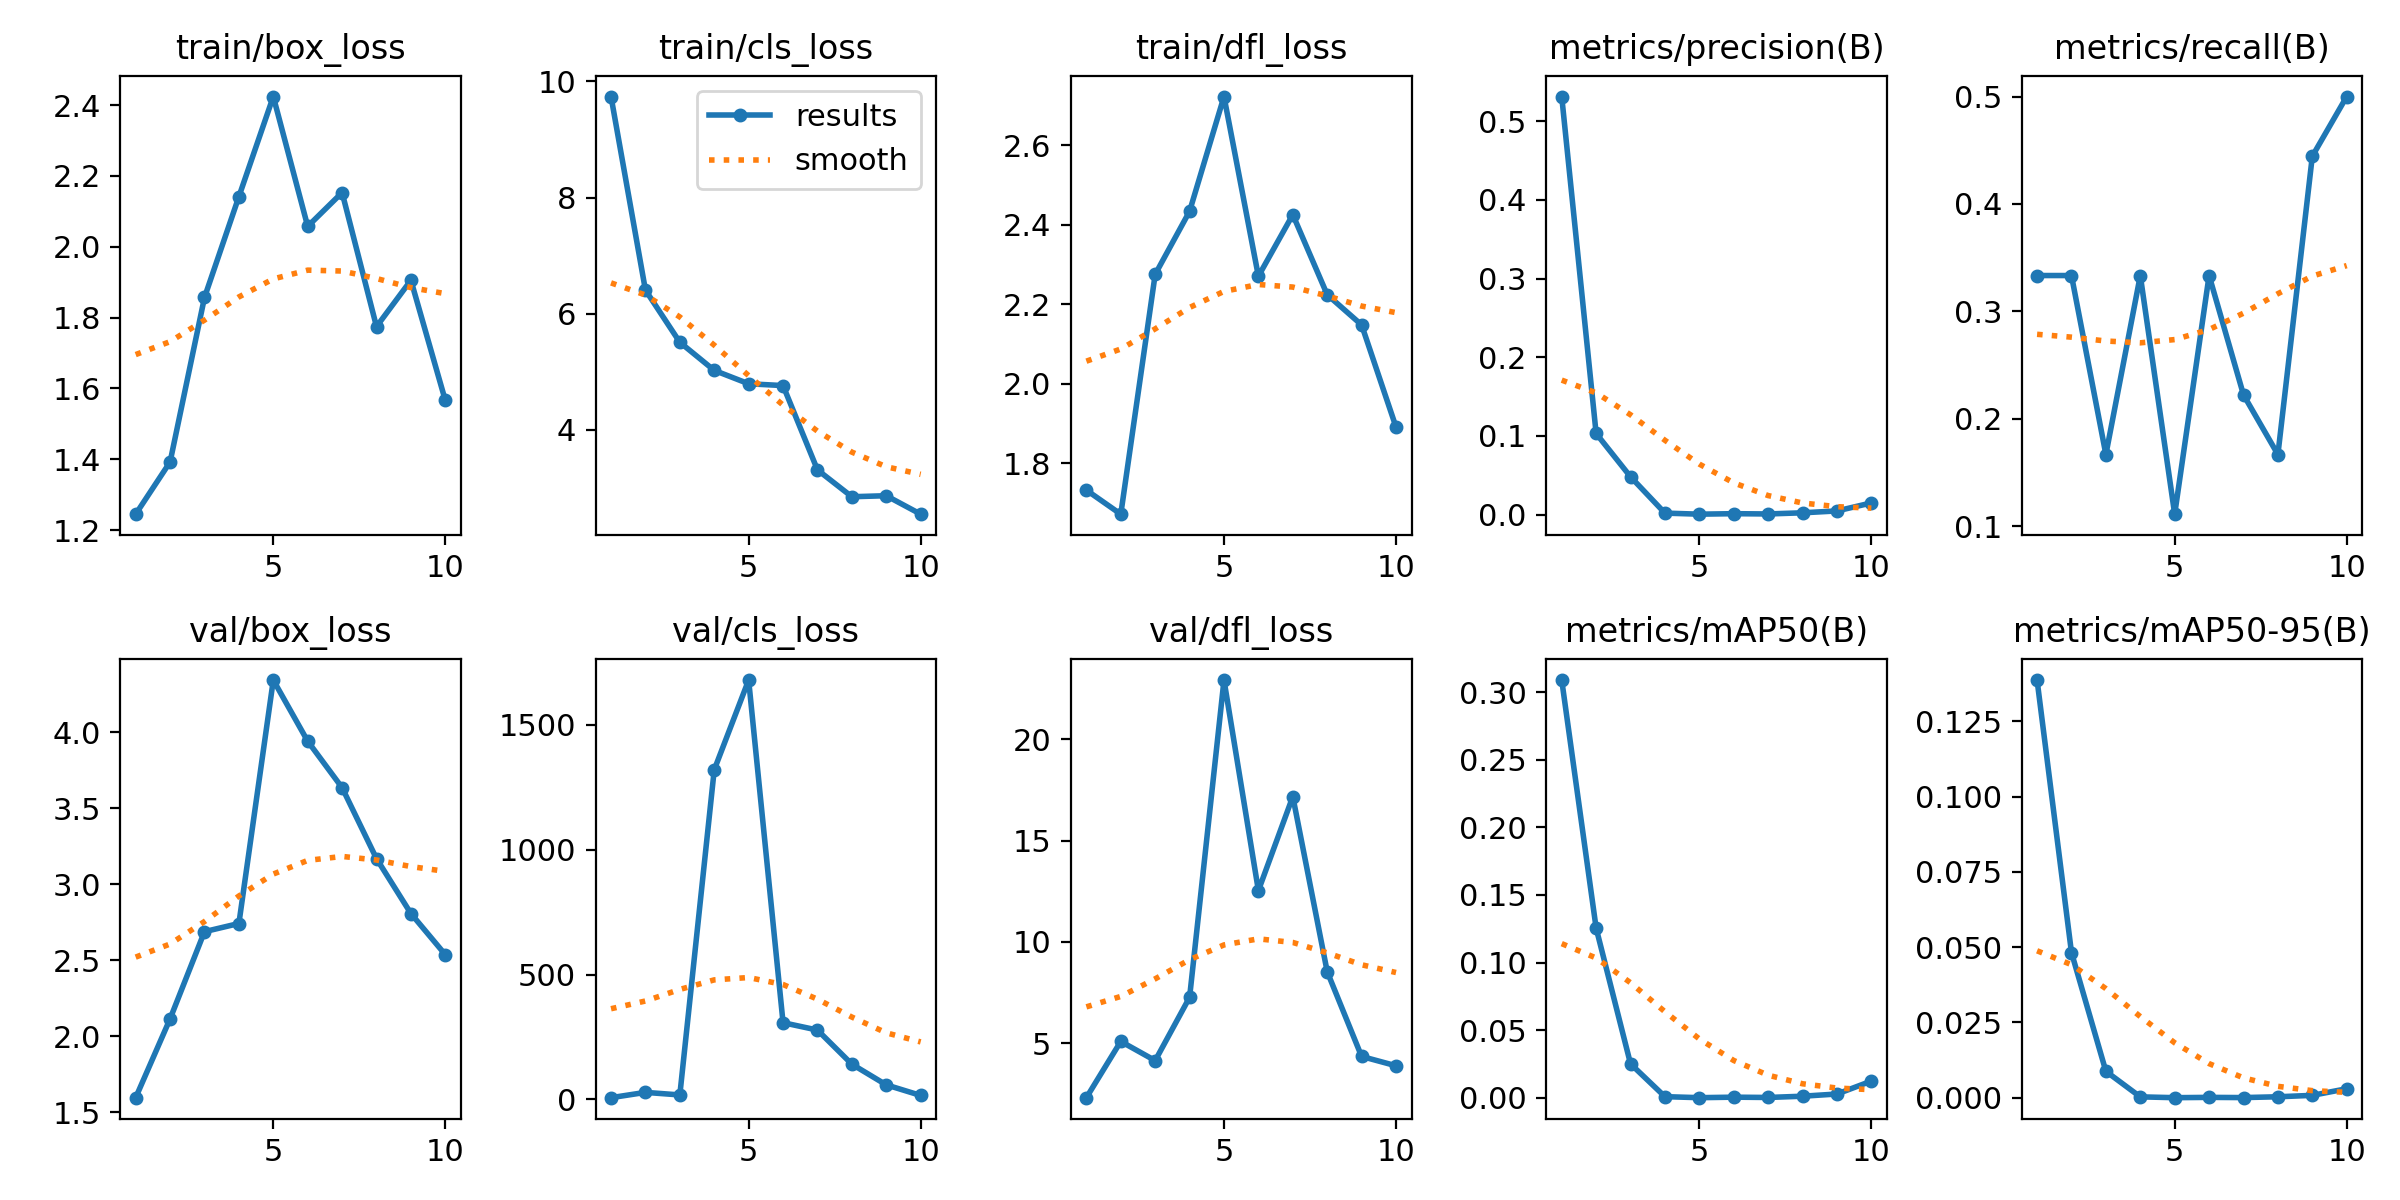

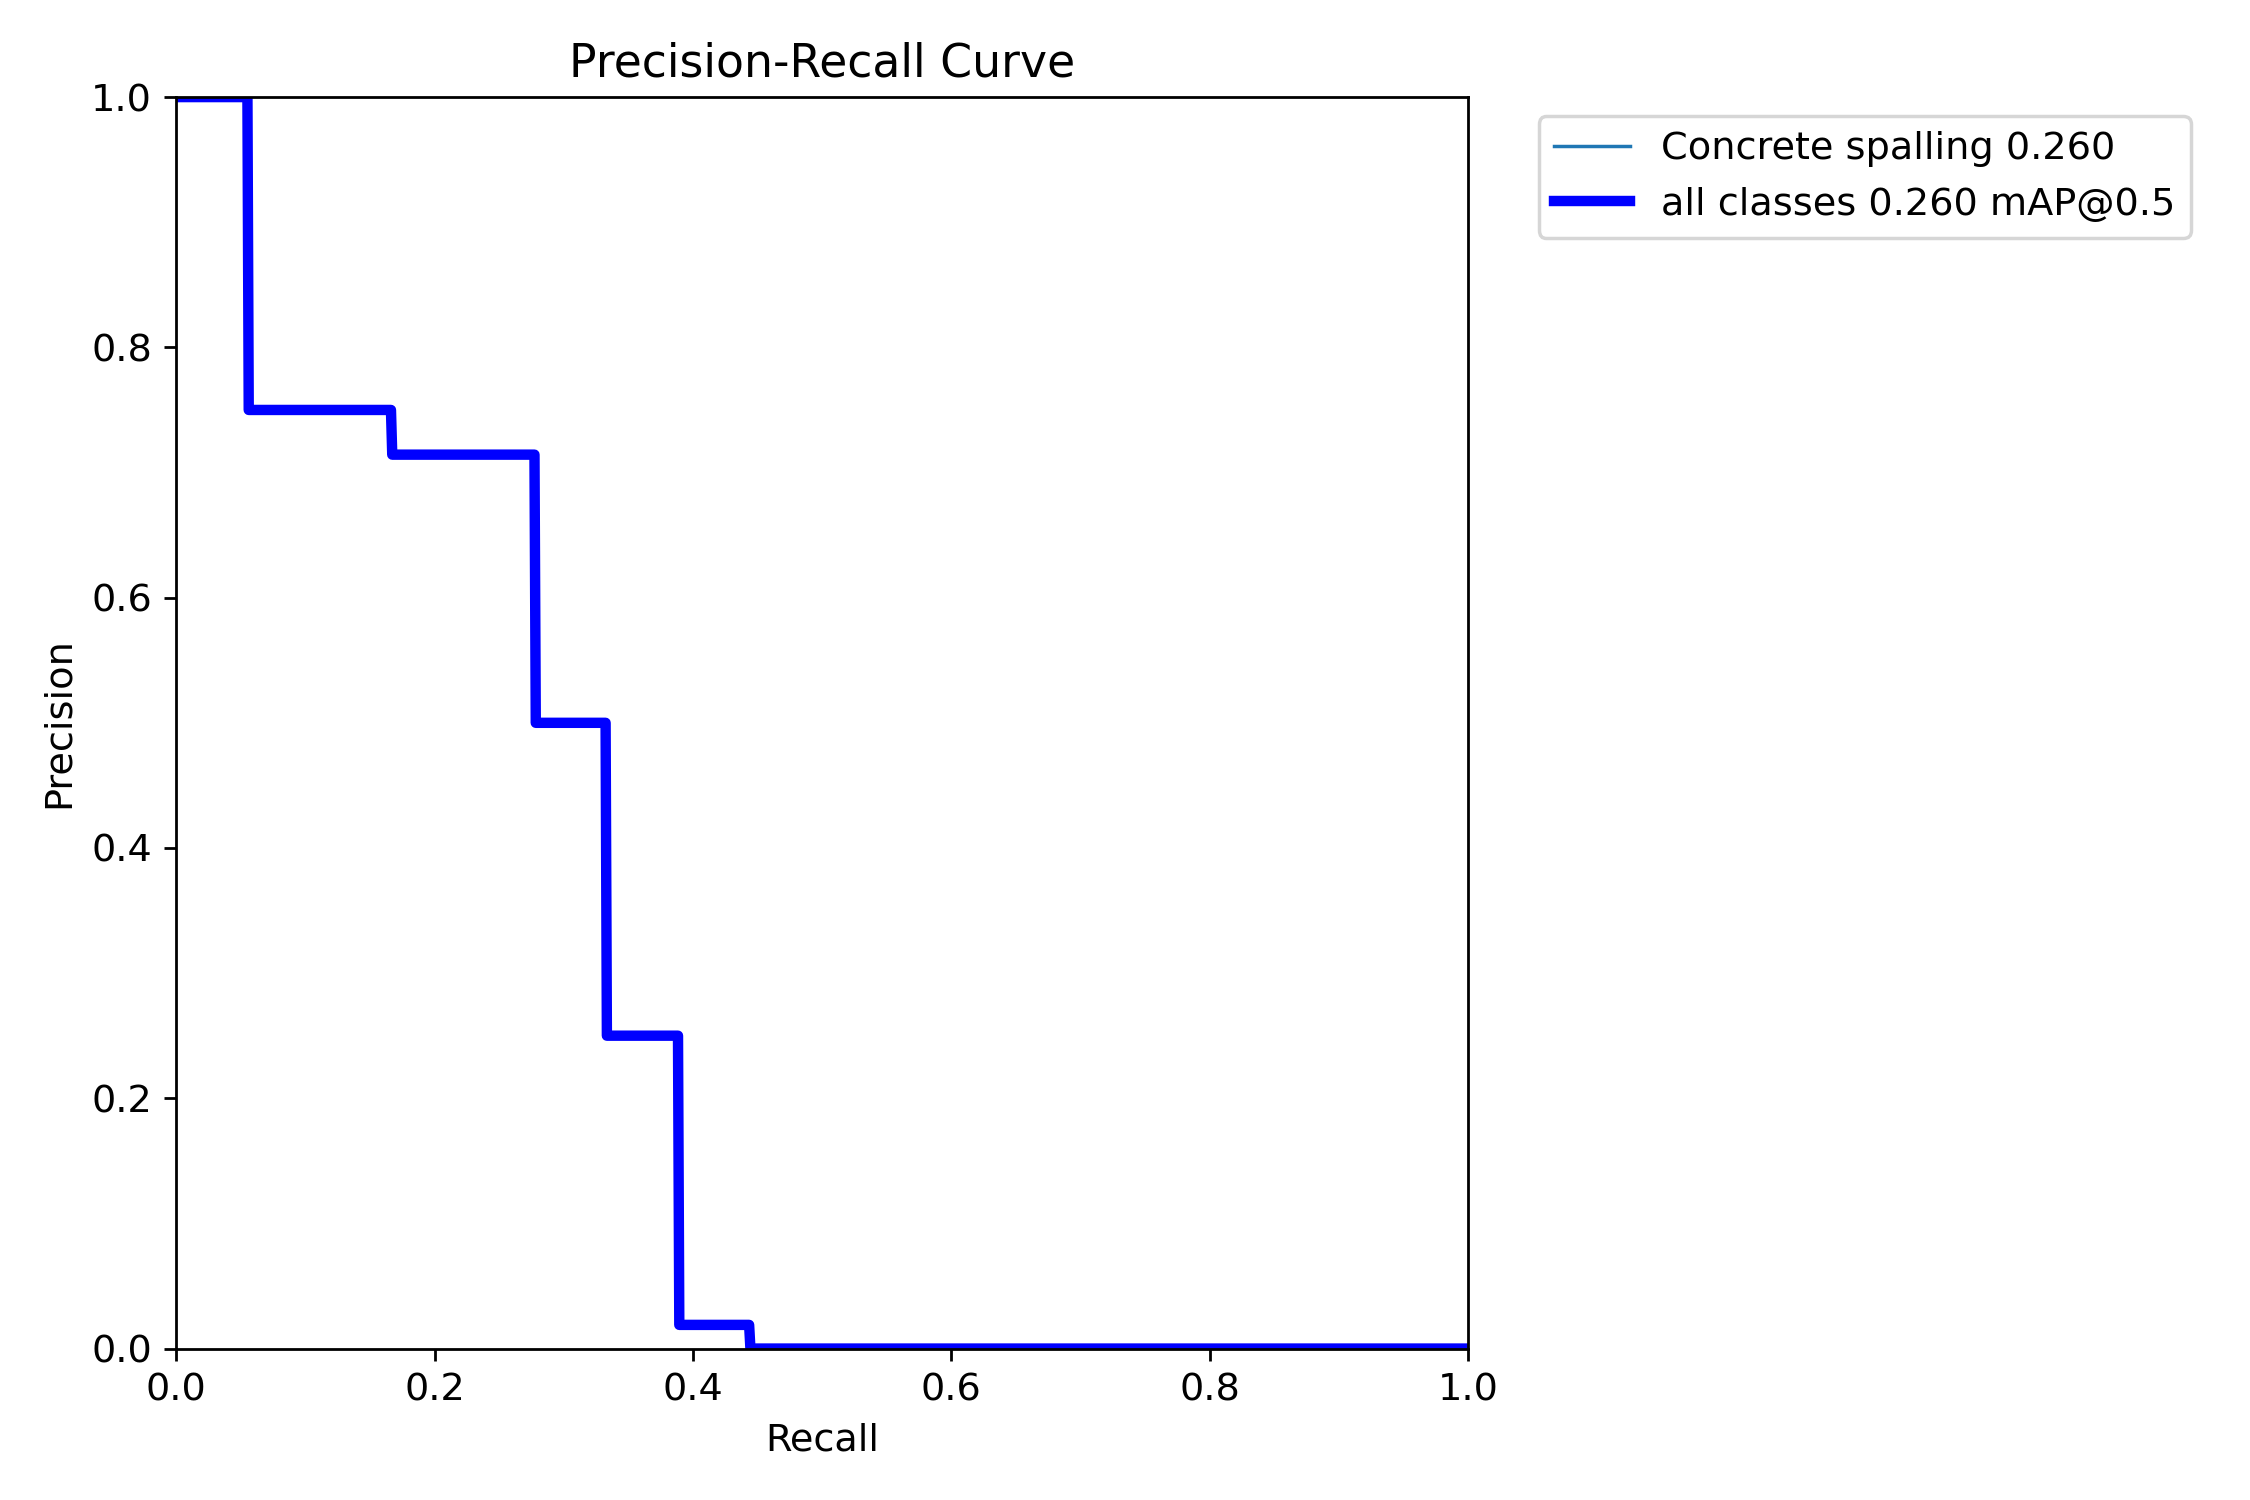

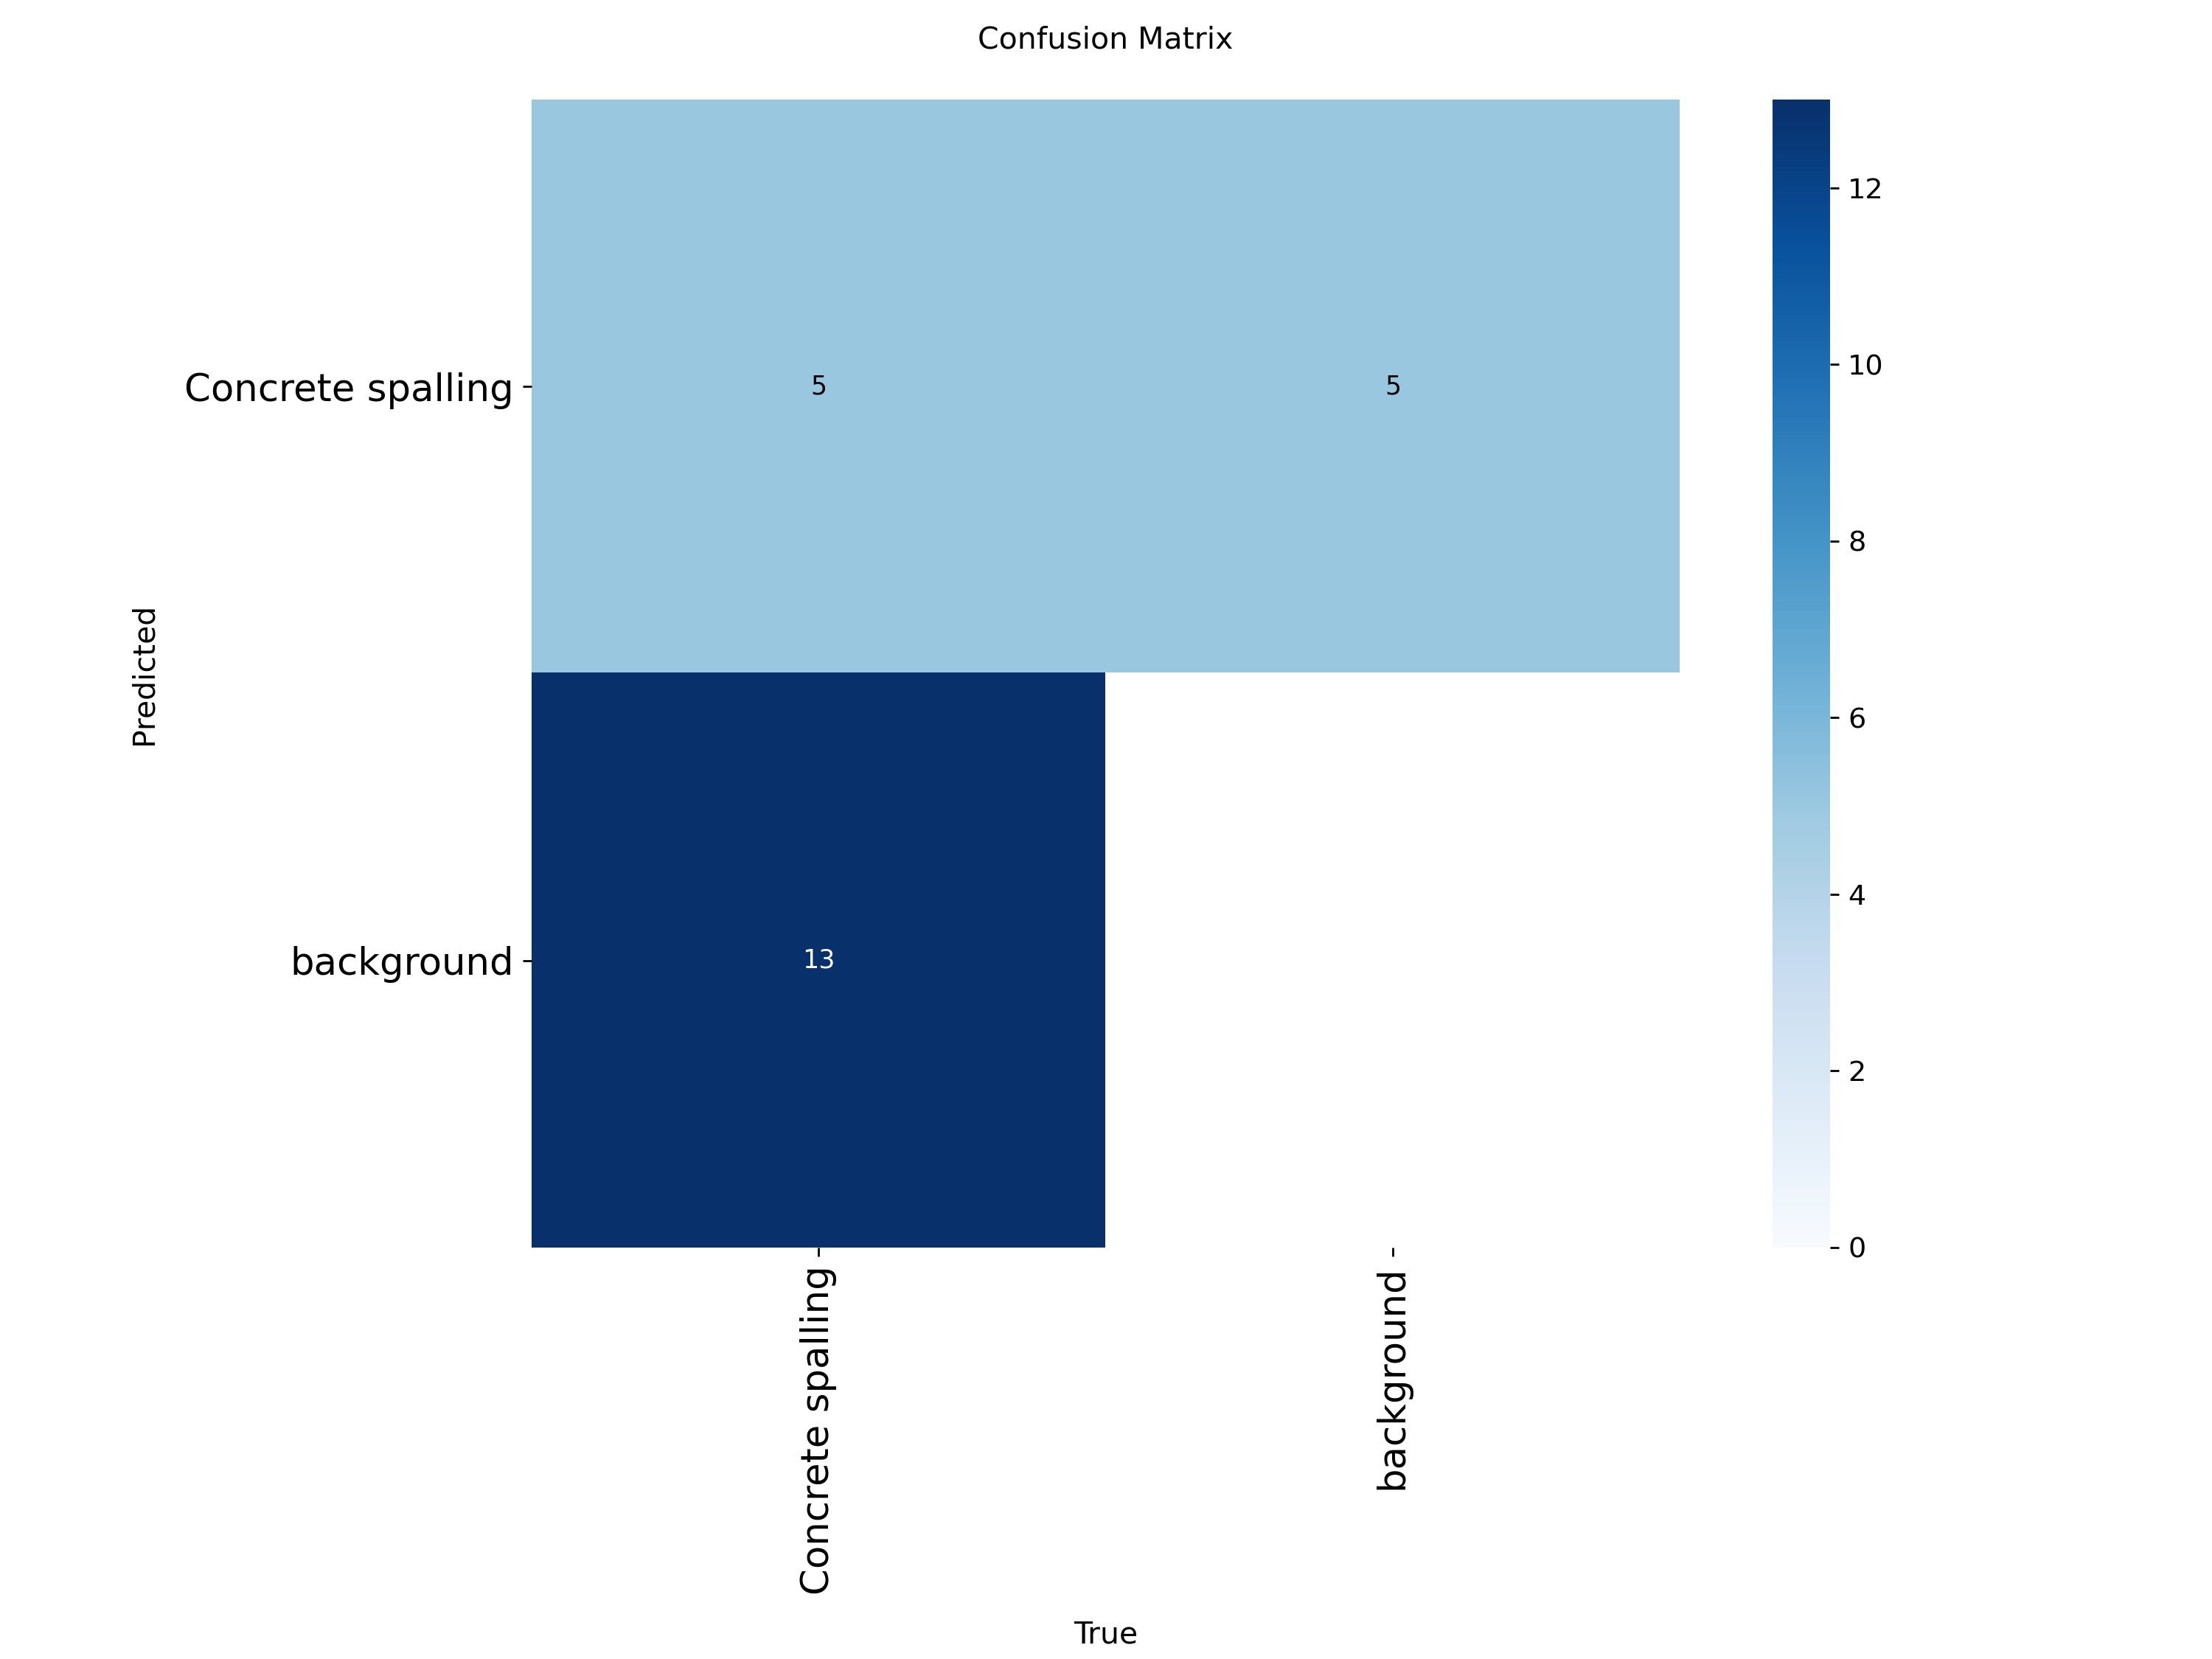

In [6]:
#Install dependencies
import pandas as pd
import os
from IPython.display import Image

#Load best.pt
best_model = YOLO("/content/runs/spalling_yolo11s_run1/weights/best.pt")

#Validate the model
metrics = best_model.val(data=data, split="val")

#Create metrics table
metrics_table = pd.DataFrame({"Metric": ["Precision", "Recall", "mAP50", "mAP50-95"], "Value": [metrics.box.mp, metrics.box.mr, metrics.box.map50, metrics.box.map]})

#Show training plots
run_dir = "/content/runs/spalling_yolo11s_run1"
print(os.listdir(run_dir))
display(Image(filename=f"{run_dir}/results.png"))
display(Image(filename=f"{run_dir}/BoxPR_curve.png"))
display(Image(filename=f"{run_dir}/confusion_matrix.png"))